# Experiment 3 — LightGBM/XGBoost probability blending

**Question / hypothesis.** Do the nearly tied LightGBM and XGBoost models make sufficiently different ranking errors for a simple probability blend to improve ROC AUC?

**Held constant.** Experiment 2 configurations, preprocessing, raw features, and the exact five folds are unchanged. Public scores are context only and are not used for selection.

**Changed.** Only the LightGBM/XGBoost blend weight varies in 0.1 increments.

The analysis uses paired complete OOF predictions, diversity diagnostics, and bootstrap uncertainty rather than treating the numerically best weight as automatically meaningful.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
blends = pd.read_csv(ROOT / 'reports/blend_results.csv')
oof = pd.read_csv(ROOT / 'reports/oof_predictions_exp03.csv')
bootstrap = pd.read_csv(ROOT / 'reports/blend_bootstrap_samples.csv')
analysis = json.loads((ROOT / 'reports/blend_analysis.json').read_text())
oof.shape, oof.head()

((691369, 5),
    id  target  fold  lightgbm_oof  xgboost_oof
 0   0       1     4      0.856086     0.815260
 1   1       0     4      0.051912     0.045030
 2   2       0     4      0.472108     0.433329
 3   3       1     5      0.319910     0.324350
 4   4       1     3      0.999996     0.999923)

The full experiment can be reproduced with `uv run evaluate-blend`. That command fits 10 fold models, performs 500 full-size paired bootstrap resamples, conditionally fits both full-data models, and validates the submission. The notebook reads the persisted outputs to keep routine execution fast.

## Prediction diversity

In [2]:
diversity = analysis['diversity']
pd.Series({
    'Pearson correlation': diversity['pearson_correlation'],
    'Spearman correlation': diversity['spearman_correlation'],
    'Mean absolute probability difference': diversity['mean_absolute_probability_difference'],
    'Class disagreement rate': diversity['class_disagreement_rate'],
    'Class disagreement rate, y=0': diversity['class_disagreement_rate_y0'],
    'Class disagreement rate, y=1': diversity['class_disagreement_rate_y1'],
    'Mean absolute difference, y=0': diversity['mean_absolute_difference_y0'],
    'Mean absolute difference, y=1': diversity['mean_absolute_difference_y1'],
}).to_frame('value')

,value
Pearson correlation,0.994432
Spearman correlation,0.991288
Mean absolute probability difference,0.018883
Class disagreement rate,0.019905
"Class disagreement rate, y=0",0.034078
"Class disagreement rate, y=1",0.014101
"Mean absolute difference, y=0",0.030130
"Mean absolute difference, y=1",0.014276


In [3]:
pd.Series(diversity['absolute_difference_quantiles'], name='absolute_probability_difference').to_frame()

,absolute_probability_difference
0.0,3.818631e-10
0.25,3.968745e-04
0.5,5.103797e-03
0.75,2.501761e-02
0.9,5.662039e-02
0.95,8.029522e-02
0.99,1.369331e-01
1.0,9.999954e-01


The predictions are highly correlated, but disagreement concentrates more strongly among true negatives. This leaves enough ranking diversity for blending to help.

## Weight grid

In [4]:
blends.style.format('{:.6f}')

,lightgbm_weight,xgboost_weight,oof_auc,log_loss,delta_auc_vs_lightgbm,delta_auc_vs_xgboost
0,0.000000,1.000000,0.960596,0.231060,-0.000007,0.000000
1,0.100000,0.900000,0.960755,0.230670,0.000151,0.000158
2,0.200000,0.800000,0.960878,0.230353,0.000274,0.000282
3,0.300000,0.700000,0.960967,0.230104,0.000364,0.000371
4,0.400000,0.600000,0.961023,0.229922,0.000419,0.000426
5,0.500000,0.500000,0.961044,0.229809,0.000441,0.000448
6,0.600000,0.400000,0.961032,0.229765,0.000429,0.000436
7,0.700000,0.300000,0.960987,0.229796,0.000383,0.000390
8,0.800000,0.200000,0.960906,0.229910,0.000302,0.000309
9,0.900000,0.100000,0.960785,0.230128,0.000182,0.000189


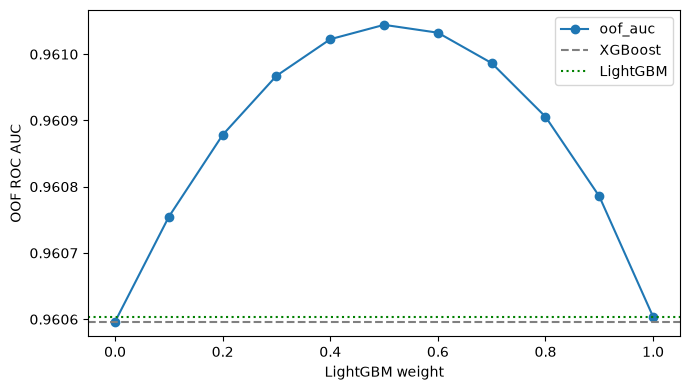

In [5]:
ax = blends.plot(x='lightgbm_weight', y='oof_auc', marker='o', legend=False, figsize=(7, 4))
ax.axhline(blends.iloc[0].oof_auc, color='gray', linestyle='--', label='XGBoost')
ax.axhline(blends.iloc[-1].oof_auc, color='green', linestyle=':', label='LightGBM')
ax.set(xlabel='LightGBM weight', ylabel='OOF ROC AUC')
ax.legend()
plt.tight_layout()

The numerical AUC optimum is 50/50 at 0.961044. All interior weights from 0.1 through 0.9 beat both individuals, and 0.4–0.6 are within about 0.000021 AUC, so the optimum is broad rather than sharp.

## Paired stratified bootstrap

In [6]:
pd.DataFrame(analysis['bootstrap']).T[[
    'mean', 'ci_95_lower', 'ci_95_upper', 'proportion_positive', 'n_resamples', 'seed'
]].style.format('{:.6f}')

,mean,ci_95_lower,ci_95_upper,proportion_positive,n_resamples,seed
blend_minus_lightgbm,0.000440,0.000390,0.000487,1.000000,500.000000,42.000000
blend_minus_xgboost,0.000449,0.000409,0.000488,1.000000,500.000000,42.000000


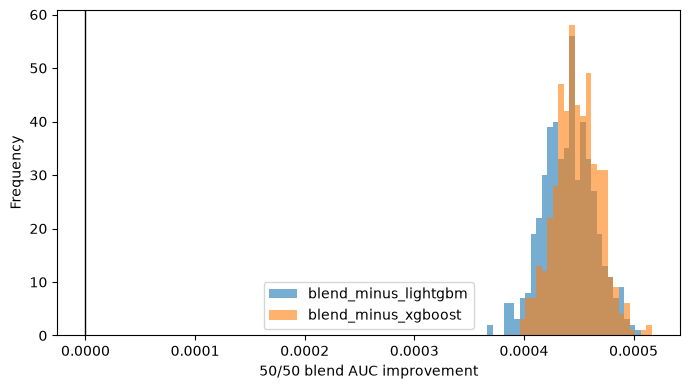

In [7]:
bootstrap[['blend_minus_lightgbm', 'blend_minus_xgboost']].plot.hist(
    bins=30, alpha=0.6, figsize=(7, 4)
)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('50/50 blend AUC improvement')
plt.tight_layout()

## Conclusion

The two component predictions are highly correlated, yet their residual ranking differences are useful: every interior weight beats both standalone models, and the optimum is broad. The 50/50 blend reaches **0.961044 OOF AUC**; paired bootstrap intervals for its gain over each component exclude zero.

**Promoted:** the simple 50/50 blend. A finer weight search is not justified, and public leaderboard results were not used to choose it.